# 第 2 天：化学本体与世界宪法

把物质、相、容器、仪器、动作和约束组织成可执行的物理化学世界。

今天关注 ChemWorld 的底座：环境不是任意黑箱函数，而是必须通过守恒、单位、非负性、安全和动作前置条件检查的世界。


## 学习路径定位

| 项目 | 内容 |
| --- | --- |
| 阶段 | A. 进入世界 |
| 难度 | 入门 2/3 |
| 先修 | 已能执行一次完整实验，并能找到 trajectory 中的 action 和 observation。 |
| 今天只解决 | 理解物质、相、容器、操作、单位和 physical constitution 如何约束世界。 |
| 今天不要求 | 不新增物理模型，也不手改 simulator 内部参数。 |
| 本日交付 | 一个非法动作、constitution/validator 给出的原因、修复后的合法动作。 |
| 下一步如何复用 | Day 3 会在这些约束下选择仪器并解释观测成本。 |



## 课堂时间盒：每 30 分钟都有产出

建议按 3 小时工作坊使用。每一段都要留下一个小证据，不要只运行代码看到结果就继续往下翻。

| 时间 | 阶段目标 | 具体动作 | 当段产出 |
| --- | --- | --- | --- |
| 0:00-0:30 | 定位世界对象 | 查看 substance、phase、vessel、instrument、operation。 | 画出 ChemWorld 的对象清单。 |
| 0:30-1:00 | 理解单位和账本 | 检查单位、体积、温度、成本、风险和样品消耗。 | 能说明每个 ledger 字段的含义。 |
| 1:00-1:30 | 触发前置条件 | 故意提交一个非法动作并读取 invalid reasons。 | 记录一个失败动作和失败原因。 |
| 1:30-2:00 | 修复非法动作 | 用 validator 修改 payload 或操作顺序。 | 得到合法动作版本。 |
| 2:00-2:30 | 检查物理宪法 | 阅读 constitution checks，区分守恒、非负性和安全边界。 | 写出 3 条可执行物理约束。 |
| 2:30-3:00 | 连接到 task | 比较不同 task 的 allowed operations 和 instruments。 | 说明 task 是世界切片而不是新游戏。 |

教师提示：如果课堂时间少于 3 小时，可以把最后两个时间盒改成课后提交；但前四个时间盒建议现场完成。


## 本日任务梯度

| 层级 | 任务 |
| --- | --- |
| 基础任务 | 找出当前 task 允许的 operation 和 instrument。 |
| 进阶任务 | 构造一个前置条件失败的动作，并解释为什么失败是合理的。 |
| 挑战任务 | 把失败动作改写成一个合法 recipe，并说明每一步满足了什么前置条件。 |
| 反思问题 | 如果没有物料守恒、非负性和动作前置条件，agent 会学到什么错误策略？ |



## 三小时实验工单（必须自己完成）

这一节不是演示输出，而是当天真正的工作量。请不要只从上到下运行已有单元；必须在后面的学生工作区新增自己的实验、图表、表格和文字结论。

| 序号 | 最小完成量 |
| --- | --- |
| 1 | 至少构造 4 个非法动作：缺少前置物料、非法仪器、越界温度/体积、错误操作顺序。 |
| 2 | 把每个非法动作的 validator/constitution 原因记录成表。 |
| 3 | 把其中 2 个非法动作修复为合法 recipe，并证明修复后可执行。 |
| 4 | 写 300 字解释：这些约束对应哪些真实化工安全或物料账本问题。 |

验收口径：本日交付至少应包含数据表、图或谱图、验证/评测结果、机制解释和下一步实验建议。低于这些证据量，视为只完成了演示浏览。



## 学生工作区

请从这里开始写自己的实验扩展。建议保留上方演示单元作为参考，不要直接覆盖；把你新增的实验条件、图、模型、验证结果和文字结论放在下面。

建议你在本节下面新增自己的代码单元。可从这个记录模板开始：

```python
student_work = {
    "hypothesis": "",
    "experiments_added": 0,
    "figures_created": 0,
    "verification_or_metric": "",
    "next_experiment": "",
}
```



In [1]:
import importlib
import sys
from pathlib import Path

import pandas as pd
from IPython.display import display

ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "notebooks" / "tutorials"))

tu = importlib.import_module("tutorial_utils")

pd.set_option("display.precision", 4)
OUTPUT_DIR = tu.ensure_output(2)
print("project root:", ROOT)
print("output dir:", OUTPUT_DIR)

project root: D:\Projects\ChemWorld
output dir: D:\Projects\ChemWorld\runs\tutorials\day02


## 今日任务

请先运行顶部导入单元，确认 kernel 指向项目虚拟环境；随后按顺序执行每个代码单元，观察表格、图形和验证结果，并在最后写下自己的实验判断。


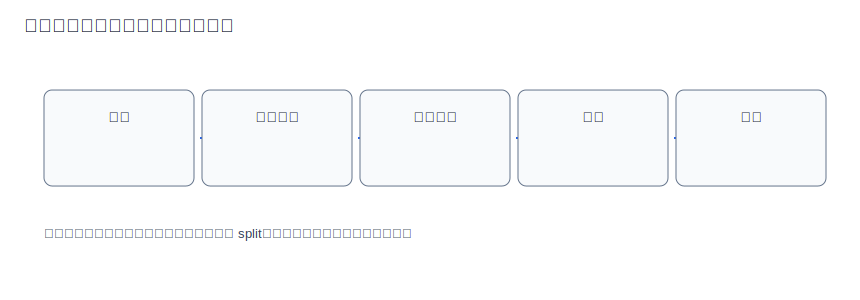

In [2]:
tu.display_tutorial_header(
    day=2,
    title='化学本体与世界宪法',
    subtitle='把物质、相、容器、仪器、动作和约束组织成可执行的物理化学世界。',
    focus=[
        '本体对象',
        '物料守恒',
        '动作前置条件',
        'constitution 检查',
    ],
    deliverables=[
        '一份 constitution 检查摘要',
        '一个失败动作示例',
        '一条关于物理约束的解释',
    ],
    project_link='leaderboard 的可信度来自这些可执行约束，而不只是最终分数。',
)
tu.display_course_map(2)
display(tu.world_law_svg())


In [3]:
tu.display_api_card()

## 第 2 天检查点

完成本 notebook 后，请确认你已经留下这些证据：

- 一张来自自己实验的轨迹表或 JSONL 文件
- 一张由自己实验数据生成的图
- 一个有化工意义的机制假设
- 一个下一轮实验建议
- 一条关于 GPT 或其他助手使用方式的记录


In [5]:
import gymnasium as gym

env = gym.make("ChemWorld", world_split="public-dev", budget=8, seed=42)
env.reset(seed=42)
task_info = env.unwrapped.task_info()
constitution = env.unwrapped.constitution_summary()
env.close()

tu.show_json_panel(
    "Task identity",
    {
        "env_id": task_info["env_id"],
        "world_id": task_info["world_id"],
        "split": task_info["world_split"],
        "family": task_info["world_family_version"],
    },
)

In [6]:
operations = pd.DataFrame(task_info["operations"])
instruments = pd.DataFrame(
    [
        {
            "id": key,
            "name": item["name"],
            "observable_keys": ", ".join(item["observable_keys"]),
            "cost": item["cost"],
            "sample_volume_L": item["sample_volume_L"],
            "requires_terminated": item["requires_terminated"],
        }
        for key, item in task_info["instruments"].items()
    ]
)
display(operations[["id", "required_fields", "preconditions"]])
display(instruments)

,id,required_fields,preconditions
0,add_reagent,[amount_mol],[not_terminated]
1,add_solvent,"[volume_L, solvent]",[not_terminated]
2,add_catalyst,"[catalyst_amount_mol, catalyst]",[not_terminated]
3,heat,"[target_temperature_K, duration_s, stirring_sp...","[has_volume, has_material]"
4,wait,"[duration_s, stirring_speed_rpm]","[has_volume, has_material]"
5,sample,[sample_volume_L],[has_volume]
6,quench,[],[has_volume]
7,add_phase,"[phase, volume_L]",[not_terminated]
8,add_extractant,"[extractant, volume_L]","[has_volume, has_material, not_terminated]"
9,mix,"[duration_s, stirring_speed_rpm]",[has_phase_system]


,id,name,observable_keys,cost,sample_volume_L,requires_terminated
0,hplc,HPLC,"yield, selectivity, byproduct_signal, purity, ...",0.080,2.0000e-04,False
1,gc,GC,"byproduct_signal, degradation_warning",0.060,1.5000e-04,False
2,uvvis,UV-vis,"yield, conversion, phase_ratio",0.025,5.0000e-05,False
3,final_assay,Final assay,"yield, selectivity, conversion, byproduct_sign...",0.160,3.0000e-04,True


In [7]:
print("constitution passed:", constitution["passed"])
display(pd.DataFrame(constitution["checks"]).head(16))
print("rules:")
for rule in constitution["rules"]:
    print("-", rule)

constitution passed: True


,name,passed,message,value,tolerance
0,nonnegative:amount:A,True,amount:A=0.0,0.00,5.0000e-07
1,nonnegative:amount:P,True,amount:P=0.0,0.00,5.0000e-07
2,nonnegative:amount:B,True,amount:B=0.0,0.00,5.0000e-07
3,nonnegative:amount:D,True,amount:D=0.0,0.00,5.0000e-07
4,nonnegative:amount:E,True,amount:E=0.0,0.00,5.0000e-07
5,nonnegative:amount:Cat_active,True,amount:Cat_active=0.0,0.00,5.0000e-07
6,nonnegative:amount:Cat_dead,True,amount:Cat_dead=0.0,0.00,5.0000e-07
7,nonnegative:volume_L,True,volume_L=0.0,0.00,5.0000e-07
8,nonnegative:temperature_K,True,temperature_K=298.15,298.15,5.0000e-07
9,nonnegative:pressure_Pa,True,pressure_Pa=101325.0,101325.00,5.0000e-07


rules:
- material_conservation
- nonnegative_state
- unit_consistency
- yield_upper_bound
- energy_balance
- phase_mass_balance
- observation_non_omniscient
- measurement_has_cost
- action_preconditions
- safety_constraints
- public_private_reproducibility


In [8]:
from chemworld.foundation.units import convert_value, supported_units

unit_table = pd.DataFrame(
    [
        {
            "unit": unit,
            "dimension": spec.dimension,
            "canonical_unit": spec.canonical_unit,
        }
        for unit, spec in supported_units().items()
    ]
)
display(unit_table)
print("25 degC in K:", convert_value(25.0, "degC", "K"))
print("2.5 h in s:", convert_value(2.5, "h", "s"))
print("125 mL in L:", convert_value(125.0, "mL", "L"))

,unit,dimension,canonical_unit
0,J,energy,J
1,K,temperature,K
2,L,volume,L
3,Pa,pressure,Pa
4,bar,pressure,Pa
5,currency,cost,currency
6,degC,temperature,K
7,dimensionless,dimensionless,dimensionless
8,h,time,s
9,kJ,energy,J


25 degC in K: 298.15
2.5 h in s: 9000.0
125 mL in L: 0.125


In [9]:
bad_events = [
    {"operation": "measure", "instrument": "final_assay"},
    {"operation": "heat", "target_temperature_K": 390.0, "duration_s": 300.0},
]
bad_run = tu.run_events(bad_events, seed=13)
display(
    bad_run[
        [
            "step",
            "operation",
            "instrument",
            "reward",
            "measurement_cost",
            "sample_consumed",
            "precondition_failed",
            "observed_keys",
            "error_message",
        ]
    ]
)
assert bad_run["precondition_failed"].all()
assert bad_run["observed_keys"].eq("").all()
assert bad_run[["yield", "selectivity", "conversion", "score"]].isna().all().all()

,step,operation,instrument,reward,measurement_cost,sample_consumed,precondition_failed,observed_keys,error_message
0,1,measure,final_assay,0.0,0.0,0.0,True,,"Action precondition failed: has_volume, measur..."
1,2,heat,None,0.0,0.0,0.0,True,,"Action precondition failed: has_volume, has_ma..."


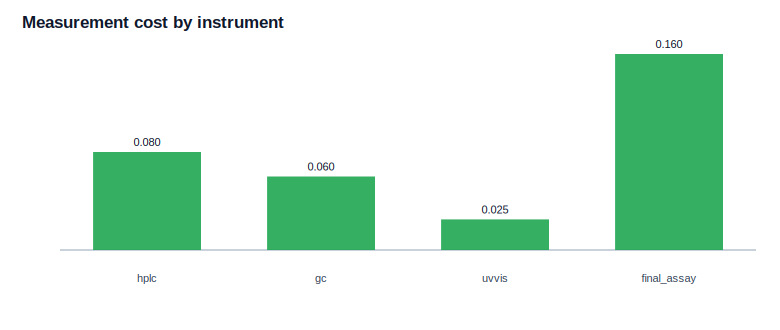

In [10]:
display(
    tu.bar_svg(
        instruments["id"].tolist(),
        instruments["cost"].astype(float).tolist(),
        title="Measurement cost by instrument",
        color="#16a34a",
    )
)

## 当天练习

解释为什么 `final_assay` 需要 `terminate` 之后才能做。再找一个你认为应该被
constitution 检查捕获的错误动作，并尝试构造出来。


## 课后反思

请用两三句话回答下面的问题，并把答案写进当天的实验日志。


In [11]:
tu.display_reflection_box(
    [
        '哪一条 constitution rule 最像真实实验室规则？',
        '如果 agent 能绕过这些规则，会造成什么评测问题？',
    ]
)
